In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
visa_df=pd.read_csv("Visadataset.csv")
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


In [3]:
cat=visa_df.select_dtypes(include='str').columns.tolist()
num=visa_df.select_dtypes(exclude='str').columns.tolist()
cat,num

(['case_id',
  'continent',
  'education_of_employee',
  'has_job_experience',
  'requires_job_training',
  'region_of_employment',
  'unit_of_wage',
  'full_time_position',
  'case_status'],
 ['no_of_employees', 'yr_of_estab', 'prevailing_wage'])

# why_Scaling

- scaling presreve the numerical statbility across the columns
    - ex: age:20      salary:50000     exp:2

    - different columns having the different scale(limit)

    - we want to keep all the columns under same limit

    - if we donot keep under same scale some ml algo feels salary is the important column
        - becuase of the highest value
- **faster training**
    - some ml algorithms like**KNN,KMEANS,SVM** are different distance based algorithms
    - if we lower the values tha calculation are fast
    - in every model development will do math calculation
    - in odder to increase the fastness(optimization) scaling is very importent

# z_score

- normalization scaling:0 to 1
- standard scaling:-3 to 3

In [32]:
#step1 :wage_mean=wage_data.mean()
# step 2:wage_sd
# step3: Nr=wage_data-wage_mean
#step4:Nr/wage_sd


# wage_data=visa_df['prevailing_wage']

# wage_mean=wage_data.mean()
# wage_sd=wage_data.std()
# Nr=wage_mean-wage_sd
# wage_z=Nr/wage_sd


wage_data = visa_df['prevailing_wage']

wage_mean = wage_data.mean()
wage_sd = wage_data.std()

Nr = wage_mean - wage_sd

wage_z = Nr / wage_sd



TypeError: object of type 'numpy.float64' has no len()

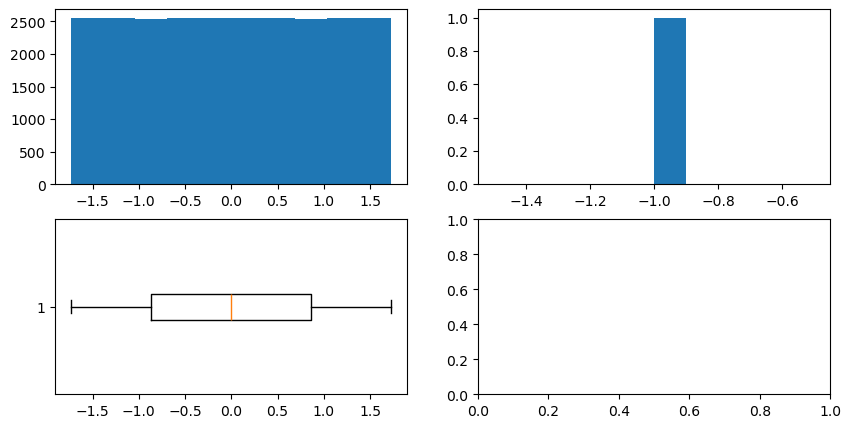

In [33]:
plt.figure(figsize=(10,5))
plt.subplot(2,2,1).hist(wage_data_ss)
plt.subplot(2,2,2).hist(wage_z)
plt.subplot(2,2,3).boxplot(wage_data_ss,vert=False)
plt.subplot(2,2,4).boxplot(wage_z,vert=False)
plt.show()

In [28]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
visa_df['prevailing_wage']=ss.fit_transform(visa_df[['prevailing_wage']])

In [26]:
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,1587,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,15091,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,21194,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,15095,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,23611,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,13946,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,25413,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,23396,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,15565,Year,Y,Certified


# Normalization

In [ ]:
- standardScaler is called as aZ score
- Min Max Scalar is called as Norm 0 to 1
    

In [37]:
wage_data = visa_df['prevailing_wage']
wage_data

0       -1.514565
1        0.322514
2        1.152764
3        0.323058
4        1.481571
           ...   
25475    0.166748
25476    1.726715
25477    1.452323
25478    0.386997
25479    0.013024
Name: prevailing_wage, Length: 25480, dtype: float64

In [40]:
wage_min=wage_data.min()
wage_min
wage_max=wage_data.max()
wage_max
Nr=wage_data-wage_min
Nr
Dr=wage_max-wage_min
Dr
wage_norm=Nr/Dr
wage_norm

0        0.062350
1        0.592897
2        0.832672
3        0.593054
4        0.927631
           ...   
25475    0.547912
25476    0.998428
25477    0.919184
25478    0.611519
25479    0.503516
Name: prevailing_wage, Length: 25480, dtype: float64

In [43]:
from sklearn.preprocessing import MinMaxScaler
mm = MinMaxScaler()
visa_df['prevailing_wage'] = mm.fit_transform(
    visa_df[['prevailing_wage']]
)

In [44]:
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,0.062350,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,0.592897,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,0.832672,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,0.593054,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,0.927631,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,0.547912,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,0.998428,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,0.919184,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,0.611519,Year,Y,Certified
